<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/ImageClassifierCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# dataset

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

In [16]:
# Option 1: huggingface parquet format data
from datasets import load_dataset

dataset_from_hub = load_dataset("ParamDev/ImageClassification")

train_data_from_hub = dataset_from_hub["train"]
test_data_from_hub = dataset_from_hub["test"]

dataset_from_hub

In [3]:
import os
from PIL import Image

# Create directories for saving images if they don't exist
if not os.path.exists("train/dogs"):
    os.makedirs("train/dogs")
if not os.path.exists("train/cats"):
    os.makedirs("train/cats")
if not os.path.exists("test/dogs"):
    os.makedirs("test/dogs")
if not os.path.exists("test/cats"):
    os.makedirs("test/cats")

# Function to save images
def save_images(dataset, split_name):
    for i, example in enumerate(dataset):
        image = example["image"]
        label = example["label"] # 0 for cat, 1 for dog

        # Determine the directory based on the label
        if label == 0:
            label_dir = "cats"
        else:
            label_dir = "dogs"

        # Save the image
        image_path = os.path.join(split_name, label_dir, f"image_{i}.jpg")
        image.save(image_path)

# Save train and test images
save_images(train_data_from_hub, "train")
save_images(test_data_from_hub, "test")

print("Images saved to train/dogs, train/cats, test/dogs, and test/cats directories.")

Images saved to train/dogs, train/cats, test/dogs, and test/cats directories.


In [4]:
# Use Generators for large datasets
train_data = keras.utils.image_dataset_from_directory(
              directory = "/content/train/",
              labels="inferred", # folder names
              label_mode="int",  # encoded
              class_names=None,  # can remove this here
              color_mode="rgb",  # for channels
              batch_size=32,
              image_size=(256, 256),
              shuffle=True,
)
test_data = keras.utils.image_dataset_from_directory(
              directory = "/content/test/",
              labels="inferred",
              label_mode="int",
              class_names=None,
              color_mode="rgb",
              batch_size=32,
              image_size=(256, 256),
              shuffle=True,
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [5]:
# print(train_data_from_hub[0]["label"], ":")
# train_data_from_hub[0]["image"]

In [6]:
# print(train_data_from_hub[10000]["label"], ":")
# train_data_from_hub[10000]["image"]

In [7]:
train_data_from_hub

Dataset({
    features: ['image', 'label'],
    num_rows: 20000
})

In [8]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
# Normalize to 0,1 from 0,255-
def process(image, label):
  image = tf.cast(image/255. ,tf.float32)
  return image, label

train_data = train_data.map(process)
test_data = test_data.map(process)

# model

**doubt** - image size is varying. **ans** - apparently they get resized for input layer

**doubt** - shuffling is needed. **ans** - shuffling done already using generator

In [12]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), activation = "relu", padding = "valid", input_shape = (256,256,3)))
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = "relu", padding = "valid"))
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Conv2D(filters = 128, kernel_size = (3,3), activation = "relu", padding = "valid"))
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Flatten())

model.add(Dense(units = 128, activation = "relu"))
model.add(Dense(units = 64, activation = "relu"))
model.add(Dense(units = 1, activation = "sigmoid"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

history = model.fit(train_data, epochs = 5, validation_data = test_data)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.6088 - loss: 0.6719 - val_accuracy: 0.7208 - val_loss: 0.5427
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.7550 - loss: 0.4967 - val_accuracy: 0.7946 - val_loss: 0.4493
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 74ms/step - accuracy: 0.8098 - loss: 0.4114 - val_accuracy: 0.7948 - val_loss: 0.4437
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.8666 - loss: 0.3091 - val_accuracy: 0.7994 - val_loss: 0.5511
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.9301 - loss: 0.1707 - val_accuracy: 0.7820 - val_loss: 0.7428


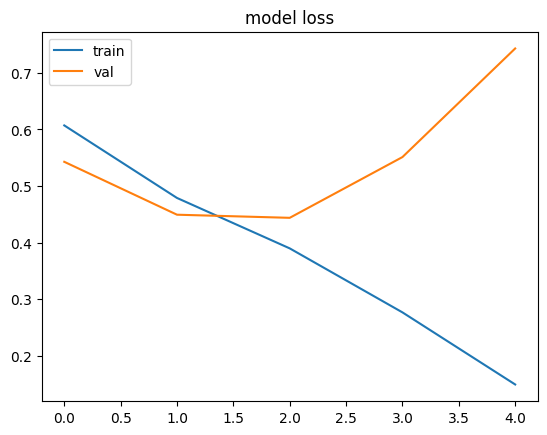

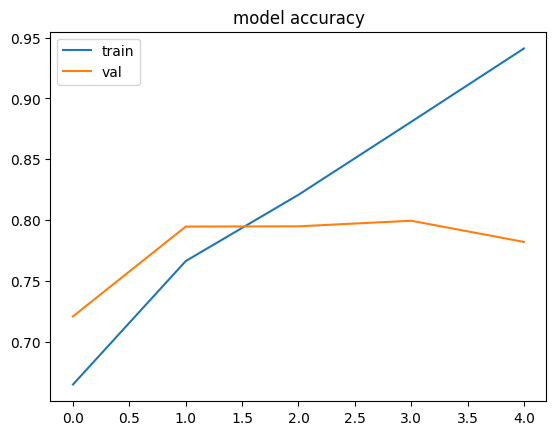

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# ways to reduce overfit in image data
# more data
# data augmentation, sampling, ...
# L1/L2 regularization
# Dropout
# batch norm
# less complexity

In [13]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), activation = "relu", padding = "valid", input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = "relu", padding = "valid"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Conv2D(filters = 128, kernel_size = (3,3), activation = "relu", padding = "valid"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Flatten())

model.add(Dense(units = 128, activation = "relu"))
model.add(Dropout(0.1))
model.add(Dense(units = 64, activation = "relu"))
model.add(Dropout(0.1))
model.add(Dense(units = 1, activation = "sigmoid"))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

history = model.fit(train_data, epochs = 5, validation_data = test_data)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - accuracy: 0.5647 - loss: 2.7963 - val_accuracy: 0.6268 - val_loss: 0.6371
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.6332 - loss: 0.6389 - val_accuracy: 0.5222 - val_loss: 0.9237
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.6594 - loss: 0.6310 - val_accuracy: 0.6592 - val_loss: 0.6315
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.7144 - loss: 0.5715 - val_accuracy: 0.7004 - val_loss: 0.5582
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - accuracy: 0.7474 - loss: 0.5161 - val_accuracy: 0.7686 - val_loss: 0.4902


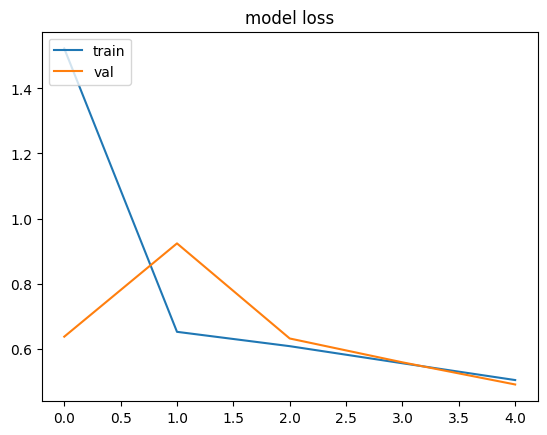

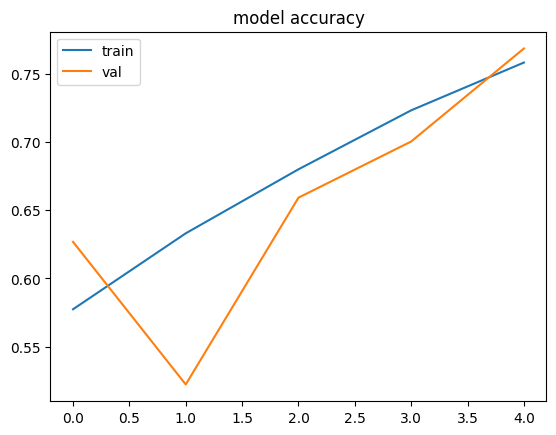

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Prediction

0 :


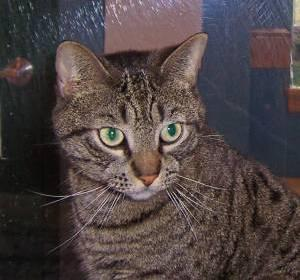

In [61]:
print(train_data_from_hub[1]["label"], ":")
train_data_from_hub[1]["image"]

(280, 300, 3)


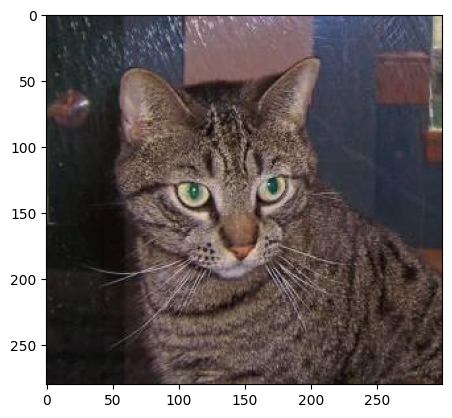

In [62]:
import numpy as np
import cv2
image = (np.array(train_data_from_hub[1]["image"])) # pil image to cv2 image
image = image.astype(np.float32) / 255.0 # normalized
print(image.shape)
plt.imshow(image)

(1, 256, 256, 3)


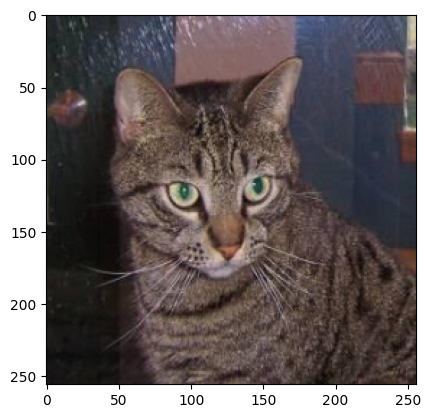

In [63]:
image = cv2.resize(image, (256,256))
image = image.reshape((1, 256, 256, 3))
print(image.shape)
plt.imshow(image[0])

In [64]:
y_hat = model.predict(image)
y_hat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[0.03110921]], dtype=float32)